<a href="https://colab.research.google.com/github/amiraatbk/Neural-network-kntu-/blob/HW2/AmirAtabaki9923413HW2NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1: import
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [ ]:
# 2: data set
x_train = np.random.uniform(-10,10,200)
y_train = 2* x_train**2 -5*x_train+ 8

In [ ]:
#3:buld network
model = keras.Sequential([
    keras.layers.Dense(60, activation='relu', input_shape=(1,)),
    keras.layers.Dense(60, activation='relu'),
    keras.layers.Dense(30, activation='relu'),
    keras.layers.Dense(30, activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 4: compile
model.compile(optimizer='adam',loss='mean_squared_error')


In [ ]:
# 5: training
model.fit(x_train, y_train, epochs=800, verbose=1)

Epoch 1/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 11044.7891
Epoch 2/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10746.9297 
Epoch 3/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11260.0020 
Epoch 4/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10241.5840 
Epoch 5/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9952.0518  
Epoch 6/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8442.9531 
Epoch 7/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5959.4229 
Epoch 8/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2931.0269 
Epoch 9/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1478.4556 
Epoch 10/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 854.5455   
Epoch 11/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 486.0519 
Epoch 12/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 582.8318 
Epoch 13/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 504.5935 
Epoch 14/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 497.0309 
Epoch 15/800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7

In [ ]:
# 6:Testing
x_test = np.linspace(-10,10,100)
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


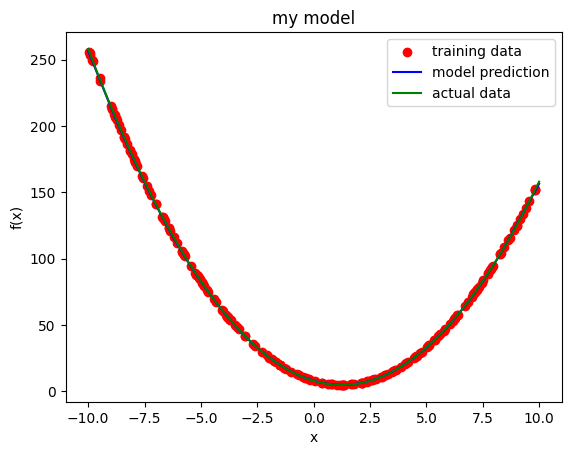

In [ ]:
# 7:plotting
plt.scatter(x_train,y_train,color='red',label="training data")
plt.plot(x_test,y_pred,color='blue',label="model prediction")
plt.plot(x_test, 2* x_test**2 -5*x_test+ 8 , color='green',label="actual data")
plt.title('my model')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

In [ ]:
# 8:Convert outputs to one-dimensional arrays
y_true = 2 * x_test.flatten()**2 - 5 * x_test.flatten() + 8
y_pred_flat = y_pred.flatten()

In [ ]:
# 9:Definition of the accuracy function for regression
def regression_accuracy(y_true, y_pred, threshold=0.1):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    relative_error = np.abs(y_true - y_pred) / np.abs(y_true)
    correct_predictions = relative_error < threshold
    accuracy = np.mean(correct_predictions) * 100
    return accuracy

In [ ]:
# 10:Calculation accuracy with an error of less than 10 percent
acc = regression_accuracy(y_true, y_pred_flat, threshold=0.1)
print(f"Regression Accuracy (~10% error margin): {acc:.2f}%")


Regression Accuracy (~10% error margin): 100.00%


In [ ]:
# 11:loss
loss = model.evaluate(x_test, y_true, verbose=0)
print(f"Mean Squared Error on test data: {loss:.3f}")

Mean Squared Error on test data: 0.152
